# Cars Analysis
## PROJECT BY AWUMBASE ENOCK ADOMBIRE

# Introduction

The automotive industry generates large volumes of data related to vehicle pricing, performance, and technical specifications. Understanding the relationships between these variables can help consumers make informed purchasing decisions and provide insights into market trends across different manufacturers.

This project presents an exploratory data analysis (EDA) of the Cars 2025 dataset, which contains information on vehicle manufacturers, prices, horsepower, top speed, acceleration, engine or battery capacity, fuel type, seating capacity, and torque.

The primary objective of this analysis is to identify patterns in car pricing and performance, compare manufacturers across key metrics, and evaluate which brands offer the best performance value. The project also demonstrates essential data analytics skills, including data cleaning, feature engineering, data visualization, correlation analysis, and outlier detection using Python.

Key questions addressed in this analysis include:

* Which manufacturers have the highest average vehicle prices?
* How does horsepower influence car prices?
* Is there a relationship between horsepower and top speed?
* Which fuel types deliver the best performance?
* Which manufacturers produce the most powerful vehicles?
* Which brands offer the best performance value relative to price?


In [3]:
#Import all data modules needed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
import seaborn as sns 

# Data Loading

In [4]:
df = pd.read_csv(r"C:\Users\awumb\Desktop\Jupyter Projects\Cars Datasets 2025.csv" , encoding='latin1')
# When you specify the encoding in pd.read_csv(), you're telling Pandas how to interpret the raw bytes in your CSV file as readable text.

In [5]:
df.head()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm


In [6]:
df.tail()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
1213,Toyota,Crown Signia,2.5L Hybrid I4,2487 cc,240 hp,180 km/h,7.6 sec,"$43,590 ?$48,000",Hybrid (Gas + Electric),5,239 Nm
1214,Toyota,4Runner (6th Gen),2.4L Turbo I4 (i-FORCE MAX Hybrid),2393 cc + Battery,326 hp,180 km/h,6.8 sec,"$50,000",Hybrid,7,630 Nm
1215,Toyota,Corolla Cross,2.0L Gas / 2.0L Hybrid,1987 cc / Hybrid batt,169 ?196 hp,190 km/h,8.0 ?9.2 sec,"$25,210 ?$29,135",Gas / Hybrid,5,190 ?210 Nm
1216,Toyota,C-HR+,1.8L / 2.0L Hybrid,1798 / 1987 cc + batt,140 ?198 hp,180 km/h,7.9 ?10.5 sec," 33,000",Hybrid,5,190 ?205 Nm
1217,Toyota,RAV4 (6th Gen),2.5L Hybrid / Plug-in Hybrid,2487 cc + batt,219 ?302 hp,200 km/h,6.0 ?8.1 sec,"$29,000 ?$43,000",Hybrid / Plug-in,5,221 ?400 Nm


In [7]:
df.shape

(1218, 11)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Names              1218 non-null   object
 1   Cars Names                 1218 non-null   object
 2   Engines                    1218 non-null   object
 3   CC/Battery Capacity        1215 non-null   object
 4   HorsePower                 1218 non-null   object
 5   Total Speed                1218 non-null   object
 6   Performance(0 - 100 )KM/H  1212 non-null   object
 7   Cars Prices                1218 non-null   object
 8   Fuel Types                 1218 non-null   object
 9   Seats                      1218 non-null   object
 10  Torque                     1216 non-null   object
dtypes: object(11)
memory usage: 104.8+ KB


In [9]:
df.describe()


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
count,1218,1218,1218,1215,1218,1218,1212,1218,1218,1218,1216
unique,37,1201,357,312,456,115,181,536,24,18,263
top,Nissan,Polo BlueMotion,I4,1984 cc,355 hp,250 km/h,6.5 sec,"$35,000",Petrol,5,400 Nm
freq,149,2,64,31,23,145,45,36,870,691,72


# DATA CLEANING

In [10]:
df.isnull().sum()

Company Names                0
Cars Names                   0
Engines                      0
CC/Battery Capacity          3
HorsePower                   0
Total Speed                  0
Performance(0 - 100 )KM/H    6
Cars Prices                  0
Fuel Types                   0
Seats                        0
Torque                       2
dtype: int64

In [11]:
#Removing Missing Values
df.dropna(inplace=True)

In [12]:
#Validating
df.shape

(1209, 11)

In [13]:
#Validating
df.isnull().sum()

Company Names                0
Cars Names                   0
Engines                      0
CC/Battery Capacity          0
HorsePower                   0
Total Speed                  0
Performance(0 - 100 )KM/H    0
Cars Prices                  0
Fuel Types                   0
Seats                        0
Torque                       0
dtype: int64

In [14]:
#Checking for duplicates
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1213    False
1214    False
1215    False
1216    False
1217    False
Length: 1209, dtype: bool

In [15]:
df.columns

Index(['Company Names', 'Cars Names', 'Engines', 'CC/Battery Capacity',
       'HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H', 'Cars Prices',
       'Fuel Types', 'Seats', 'Torque'],
      dtype='object')

In [17]:
#Cleaning Column Headers
df.columns = (
    df.columns.str.lower()
    .str.strip()
    .str.replace(r"[\[\]\(\)\$,]", "", regex=True)  # Removes [, ], (, ), $, and ,
    .str.replace(r"/", "_", regex=True)             # Replaces slashes with underscores
    .str.replace(r"\s+", "_", regex=True)           # Converts spaces to underscores
    .str.replace(r"__+", "_", regex=True)           # Merges double underscores
    .str.strip("_")                                 # Trims trailing/leading underscores
)



In [18]:
df.columns

Index(['company_names', 'cars_names', 'engines', 'cc_battery_capacity',
       'horsepower', 'total_speed', 'performance0_-_100_km_h', 'cars_prices',
       'fuel_types', 'seats', 'torque'],
      dtype='object')

In [19]:
#checking dataframe to display numerical and categorical columns.
#this is a way to cross check before EDA is done, so after checking and you see a column that's not categorical or numerical as it's supposed to be then you convert accordingly using '.astype() function
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

num_cols, cat_cols

([],
 ['company_names',
  'cars_names',
  'engines',
  'cc_battery_capacity',
  'horsepower',
  'total_speed',
  'performance0_-_100_km_h',
  'cars_prices',
  'fuel_types',
  'seats',
  'torque'])

In [20]:
numeric_cols = ['cc_battery_capacity', 'total_speed', 'seats', 'torque', 'performance0_-_100_km_h']


df[numeric_cols] = df[numeric_cols].astype(str).apply(
    lambda s: s.str.extract(r'(\d+\.?\d*)')[0].astype(float)
)

In [21]:
#Cleaning Cars Prices
import re

def clean_car_prices(x):
    x = str(x)
    
    # Remove commas and dollar signs first so numbers stay intact
    x = x.replace(',', '').replace('$', '')

    # Pattern updated to allow decimals safely
    num_in_price = re.findall(r'\d+\.?\d*', x) 
    
    if len(num_in_price) == 2:
        low, high = num_in_price
        return (float(low) + float(high)) / 2
        
    elif len(num_in_price) == 1:
        return float(num_in_price[0]) 
        
    else:
        return None 

# Applying function to clean column name
df['cars_prices'] = df['cars_prices'].apply(clean_car_prices).astype(float)


In [22]:
#Cleaning Horespower
import re 

def clean_horsepower(x):
    x = str(x)
    # .lower() lets you catch 'hp', 'HP', 'Hp', and 'hP' all at once
    x = x.lower().replace('hp', '') 

    num_in_hp = re.findall(r'\d+\.?\d*', x) 
    
    # 1. Handle Ranges
    if len(num_in_hp) == 2:
        low, high = num_in_hp 
        return (float(low) + float(high)) / 2 
        
    # 2. Handle Single Numbers safely
    elif len(num_in_hp) == 1:
        return float(num_in_hp[0])
        
    # 3. Handle Empty or Corrupted Data safely (returns None instead of crashing)
    else: 
        return None

# Apply the function globally
df['horsepower'] = df['horsepower'].apply(clean_horsepower).astype(float)


In [23]:
df.head()

,company_names,cars_names,engines,cc_battery_capacity,horsepower,total_speed,performance0_-_100_km_h,cars_prices,fuel_types,seats,torque
0,FERRARI,SF90 STRADALE,V8,3990.0,963.0,340.0,2.5,1100000.0,plug in hyrbrid,2.0,800.0
1,ROLLS ROYCE,PHANTOM,V12,6749.0,563.0,250.0,5.3,460000.0,Petrol,5.0,900.0
2,Ford,KA+,1.2L Petrol,1.0,77.5,165.0,10.5,13500.0,Petrol,5.0,100.0
3,MERCEDES,GT 63 S,V8,3.0,630.0,250.0,3.2,161000.0,Petrol,4.0,900.0
4,AUDI,AUDI R8 Gt,V10,5.0,602.0,320.0,3.6,253290.0,Petrol,2.0,560.0


In [24]:
#Converting all company names into uppercase to deal with data entry issues like('KIA' and 'Kia')
df['company_names'] = df['company_names'].str.strip().str.upper()

# EXPLORATORY DATA ANALYSIS

In [25]:
# to count specific number of cars for each company name
df['company_names'].value_counts() 

company_names
NISSAN               158
VOLKSWAGEN           109
PORSCHE               96
MAZDA                 85
KIA                   71
GMC                   59
CHEVROLET             58
MITSUBISHI            56
PEUGEOT               54
FORD                  54
TOYOTA                49
BMW                   41
JAGUAR LAND ROVER     40
ROLLS ROYCE           30
TATA MOTORS           29
ACURA                 27
LAMBORGHINI           24
HYUNDAI               23
AUDI                  21
CADILLAC              20
MERCEDES              20
JEEP                  19
VOLVO                 12
ASTON MARTIN          11
TESLA                 10
BUGATTI               10
FERRARI                9
HONDA                  7
MARUTI SUZUKI          3
MAHINDRA               3
BENTLEY                1
Name: count, dtype: int64

In [26]:
df['company_names'].unique()

array(['FERRARI', 'ROLLS ROYCE', 'FORD', 'MERCEDES', 'AUDI', 'BMW',
       'ASTON MARTIN', 'BENTLEY', 'LAMBORGHINI', 'TOYOTA', 'NISSAN',
       'VOLVO', 'KIA', 'HONDA', 'HYUNDAI', 'MAHINDRA', 'MARUTI SUZUKI',
       'VOLKSWAGEN', 'PORSCHE', 'CADILLAC', 'TATA MOTORS', 'TESLA',
       'JEEP', 'MAZDA', 'CHEVROLET', 'GMC', 'PEUGEOT', 'BUGATTI',
       'JAGUAR LAND ROVER', 'ACURA', 'MITSUBISHI'], dtype=object)

In [27]:
#Number of distinct company names
df['company_names'].nunique()

31

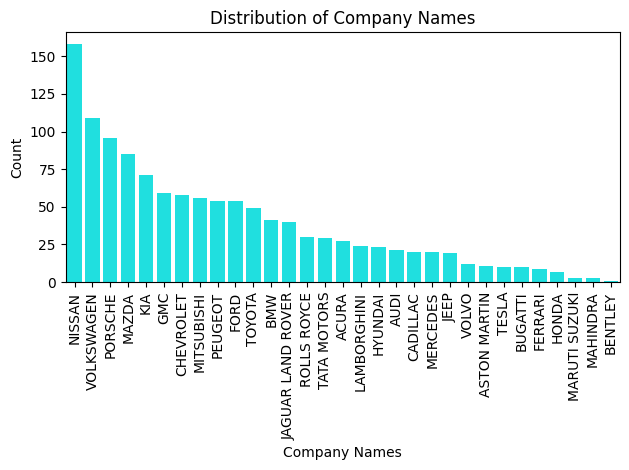

In [28]:
# Calculating the value counts
company_counts = df['company_names'].value_counts()

# Plotting with explicit x and y assignments
sns.barplot(
    x=company_counts.index,   # The company names
    y=company_counts.values,  # The counts
    color='cyan'
)

# Formating the chart text and layout
plt.title('Distribution of Company Names')
plt.xlabel('Company Names')
plt.ylabel('Count')
plt.xticks(rotation=90)       # Keeps text vertical so it does not overlap
plt.tight_layout()            # Prevents long company names from getting cut off at the bottom

plt.show()

In [29]:
df['cars_prices'].max()

np.float64(18000000.0)

In [30]:
# top 10 most expensive cars
df.nlargest(10, 'cars_prices')[['company_names', 'cars_names','cars_prices']]

,company_names,cars_names,cars_prices
887,BUGATTI,La Voiture Noire,18000000.0
886,BUGATTI,Centodieci,9000000.0
1212,MAZDA,787B (Race Car),6000000.0
885,BUGATTI,Divo,5800000.0
889,BUGATTI,Mistral,5000000.0
8,LAMBORGHINI,VENENO ROADSTER,4500000.0
888,BUGATTI,Bolide,4500000.0
882,BUGATTI,Chiron Super Sport,3500000.0
881,BUGATTI,Chiron Pur Sport,3300000.0
883,BUGATTI,Chiron Sport,3300000.0


        company_names  average_price
5             BUGATTI     5870000.00
1        ASTON MARTIN      752949.09
16        LAMBORGHINI      650083.33
8             FERRARI      512222.22
25        ROLLS ROYCE      390400.00
3             BENTLEY      311000.00
24            PORSCHE      138389.58
30              VOLVO       97083.33
19              MAZDA       94735.29
27              TESLA       87032.00
20           MERCEDES       83300.00
2                AUDI       82870.95
13  JAGUAR LAND ROVER       72125.00
4                 BMW       67317.07
10                GMC       63293.47
0               ACURA       63259.26
6            CADILLAC       62178.50
22             NISSAN       59392.03
9                FORD       53457.69
14               JEEP       51439.21
7           CHEVROLET       44962.93
28             TOYOTA       41855.15
29         VOLKSWAGEN       36301.24
15                KIA       36014.08
23            PEUGEOT       35416.67
12            HYUNDAI       31495.61
1

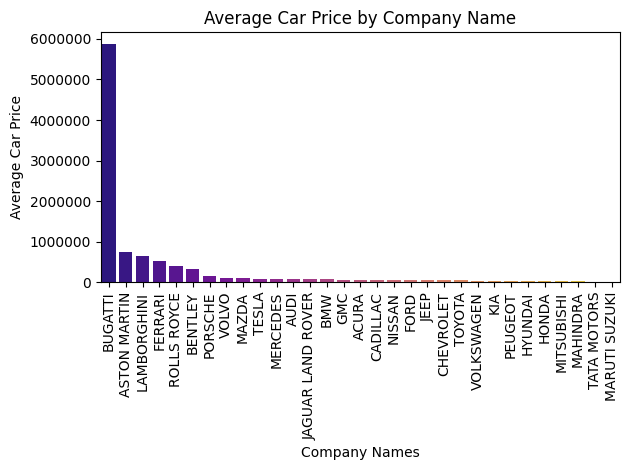

In [32]:
#Companies with the highest average car price

# 1. Calculating the average price for each company
average_prices = df.groupby('company_names')['cars_prices'].mean().reset_index()

# 2. Renaming columns for clear presentation
average_prices.columns = ['company_names', 'average_price']

# 3. Sorting from highest average price to lowest
average_prices = average_prices.sort_values(by='average_price', ascending=False)

# to show floats as regular decimals with 2 decimal places - deals with scientific notation(e.g 5000000e+06)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print(average_prices)
print()

average_prices = (
    df.groupby('company_names')['cars_prices']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)



# 2. Plotting using the sorted aggregated data
sns.barplot(
    data=average_prices, 
    x='company_names', 
    y='cars_prices', 
    hue='company_names',
     palette='plasma' # Uses a nice vibrant color gradient
)


plt.title('Average Car Price by Company Name')
plt.xlabel('Company Names')
plt.ylabel('Average Car Price')
plt.xticks(rotation=90)  
plt.ticklabel_format(style='plain', axis='y') #handles when values are too large but you still want to display all of it without it appearing as a scintific notation
plt.tight_layout()            

plt.show()

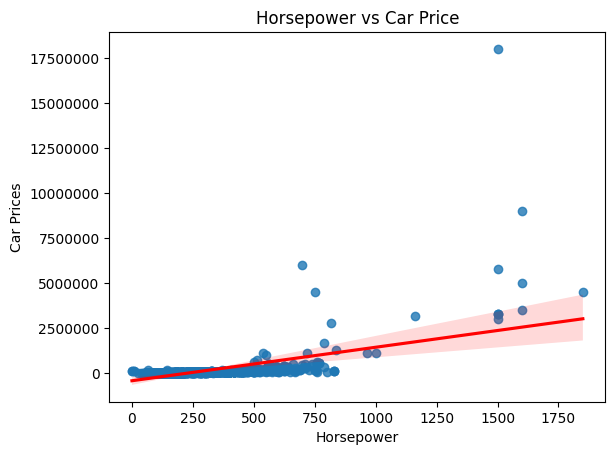

In [33]:
#horse power vs Car Price
sns.regplot(x='horsepower', y='cars_prices', data=df, line_kws={"color": "red"})
plt.title('Horsepower vs Car Price')
plt.xlabel('Horsepower')
plt.ylabel('Car Prices')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

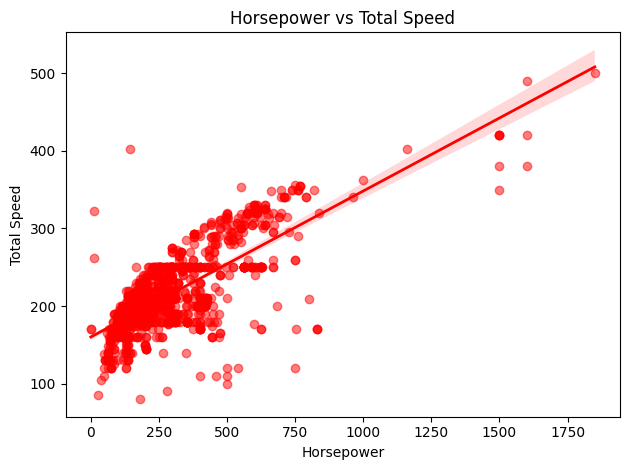

In [38]:
# Horsepower vs Total speed
sns.regplot(
    x='horsepower', 
    y='total_speed', 
    data=df, 
    color='red', 
    scatter_kws={'alpha':0.5},  # Makes dots slightly transparent to see overlapping points
    line_kws={'linewidth': 2}   # Makes the trendline crisp
)

plt.title('Horsepower vs Total Speed')
plt.xlabel('Horsepower')
plt.ylabel('Total Speed')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()

plt.show()

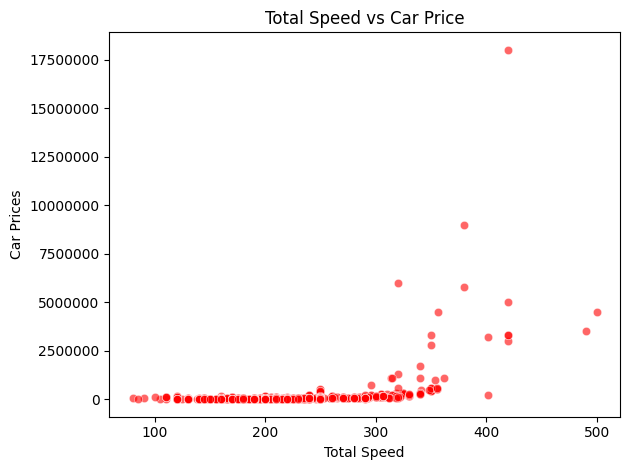

In [39]:
# Total speed vs Car Price
sns.scatterplot(
    x='total_speed', 
    y='cars_prices', 
    data=df, 
    color='red',
    alpha=0.6  # Helps you see density where many cars share the same top speed
)

plt.title('Total Speed vs Car Price')
plt.xlabel('Total Speed')
plt.ylabel('Car Prices')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()

plt.show()


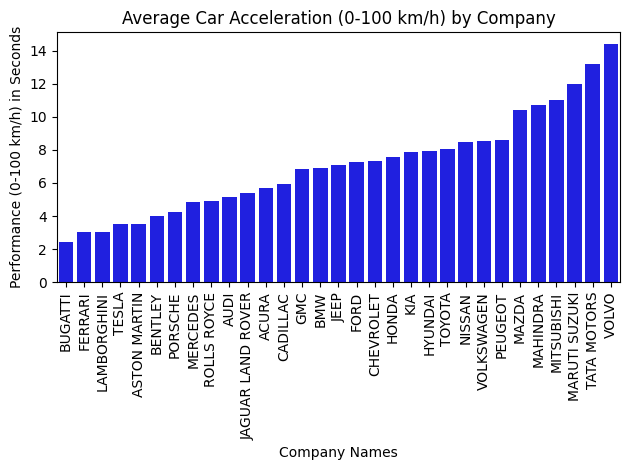

In [40]:
#car brand vs performance (company with highest acceleration) 
performance_data = (
    df.groupby('company_names')['performance0_-_100_km_h']
    .mean()
    .sort_values(ascending=True) # Ascending=True puts the fastest acceleration times (smallest seconds) first
    .reset_index()
)

# 2. Plotting using the sorted aggregated data
sns.barplot(
    data=performance_data, 
    x='company_names', 
    y='performance0_-_100_km_h', 
    color='blue'
)


plt.title('Average Car Acceleration (0-100 km/h) by Company')
plt.xlabel('Company Names')
plt.ylabel('Performance (0-100 km/h) in Seconds')
plt.xticks(rotation=90)       
plt.tight_layout()            

plt.show()


In [41]:
# missed checking this during cleaning, there are some naming conflictions with fuel types
df['fuel_types'].value_counts()

fuel_types
Petrol                     870
Diesel                     102
Electric                    95
Hybrid                      79
Petrol/Diesel               16
Petrol/Hybrid               16
Plug-in Hybrid               5
Hybrid (Petrol)              4
Diesel/Petrol                4
Petrol, Diesel               3
Hydrogen                     3
Petrol, Hybrid               2
Petrol/AWD                   2
plug in hyrbrid              1
Petrol/EV                    1
Hybrid/Electric              1
CNG/Petrol                   1
Hybrid/Petrol                1
Hybrid (Gas + Electric)      1
Gas / Hybrid                 1
Hybrid / Plug-in             1
Name: count, dtype: int64

In [42]:
#fixing conflicting fuel types
# 1. Forcing lowercase and removing extra spaces to eliminate simple casing duplicates
df['fuel_types'] = df['fuel_types'].astype(str).str.lower().str.strip()

# 2. Creating a translation dictionary to merge messy labels into unified groups
fuel_map = {
    # Plug-in Hybrids
    'plug in hybrid': 'Plug-in Hybrid',
    'hybrid / plug-in': 'Plug-in Hybrid',
    'plug-in hybrid': 'Plug-in Hybrid',
    'petrol/ev': 'Plug-in Hybrid',
    
    # Standard Hybrids
    'hybrid (petrol)': 'Hybrid',
    'hybrid/petrol': 'Hybrid',
    'petrol/hybrid': 'Hybrid',
    'hybrid': 'Hybrid',
    'hybrid (gas + electric)': 'Hybrid',
    'gas / hybrid': 'Hybrid',
    'hybrid/electric': 'Hybrid',
    'petrol, hybrid': 'Hybrid',
    
    # Pure Petrol & Drivetrain fixes
    'petrol': 'Petrol',
    'petrol/awd': 'Petrol', # Drops the AWD drivetrain tag to focus purely on Petrol
    
    # Pure Diesel
    'diesel': 'Diesel',
    
    # Alternative & Mixed Fuels
    'hydrogen': 'Hydrogen',
    'cng/petrol': 'CNG/Bi-Fuel',
    'petrol, diesel': 'Diesel/Petrol Mixed',
    'petrol/diesel': 'Diesel/Petrol Mixed',
    'diesel/petrol': 'Diesel/Petrol Mixed'
}

# 3. Apply the mapping to your column
df['fuel_types_clean'] = df['fuel_types'].map(fuel_map).fillna(df['fuel_types'].str.title())


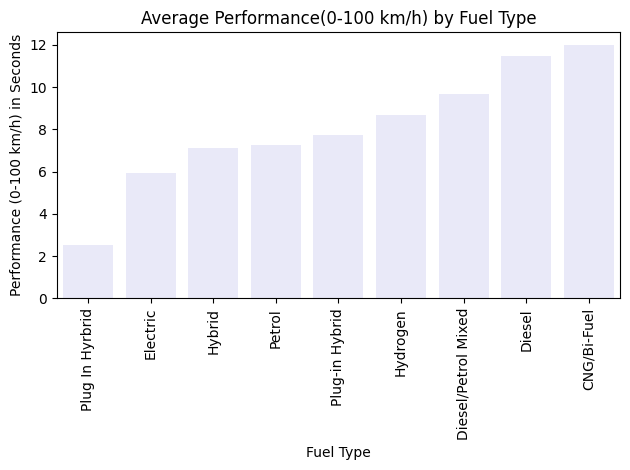

In [43]:
# fuel type vs performance (fuel type which offers the best performance)
fuel_efficiency = (
    df.groupby('fuel_types_clean')['performance0_-_100_km_h']
    .mean()
    .sort_values(ascending=True) # Ascending=True puts the fastest acceleration times (smallest seconds) first
    .reset_index()
)

# 2. Plotting using the sorted aggregated data
sns.barplot(
    data=fuel_efficiency, 
    x='fuel_types_clean', 
    y='performance0_-_100_km_h', 
    color='lavender'
)


plt.title('Average Performance(0-100 km/h) by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Performance (0-100 km/h) in Seconds')
plt.xticks(rotation=90)       
plt.tight_layout()            

plt.show()

In [44]:
# Most common fuel type
df['fuel_types_clean'].value_counts()

fuel_types_clean
Petrol                 872
Hybrid                 105
Diesel                 102
Electric                95
Diesel/Petrol Mixed     23
Plug-in Hybrid           7
Hydrogen                 3
Plug In Hyrbrid          1
CNG/Bi-Fuel              1
Name: count, dtype: int64

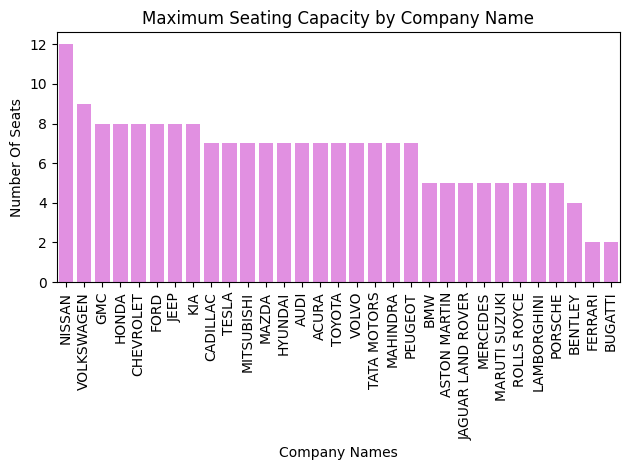

In [45]:
# Maximum Seating Capacity by Company Name
company_seats = (
    df.groupby('company_names')['seats']
    .max()
    .sort_values(ascending=False)
    .reset_index()
)

# 2. Plotting using the sorted aggregated data
sns.barplot(
    data=company_seats, 
    x='company_names', 
    y='seats', 
    color='violet'
)


plt.title('Maximum Seating Capacity by Company Name')
plt.xlabel('Company Names')
plt.ylabel('Number Of Seats')
plt.xticks(rotation=90)       
plt.tight_layout()            

plt.show()

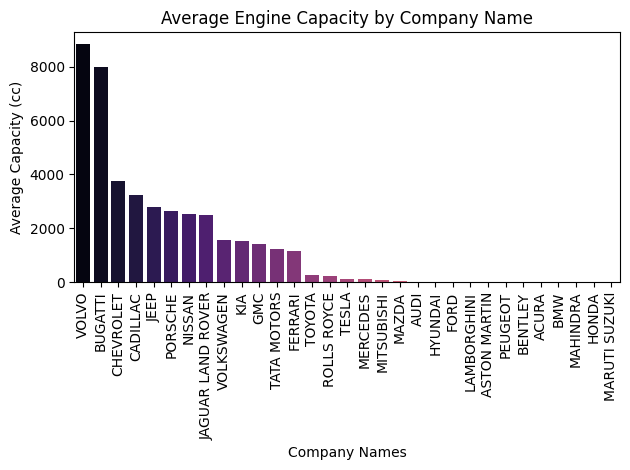

In [55]:
# Average Engine Capacity by Company Name
avg_engine_capacity = (
    df.groupby('company_names')['cc_battery_capacity']
    .mean()
    .sort_values(ascending=False) # Puts the largest engines (e.g., Bugatti V8/W16) on the left
    .reset_index()
)

# 2. Plotting using the sorted aggregated data
sns.barplot(
    data=avg_engine_capacity, 
    x='company_names', 
    y='cc_battery_capacity', 
    hue='company_names',
    palette='magma' # Uses a nice vibrant color gradient
)


plt.title('Average Engine Capacity by Company Name')
plt.xlabel('Company Names')
plt.ylabel('Average Capacity (cc)')
plt.xticks(rotation=90)       
plt.tight_layout()            

plt.show()

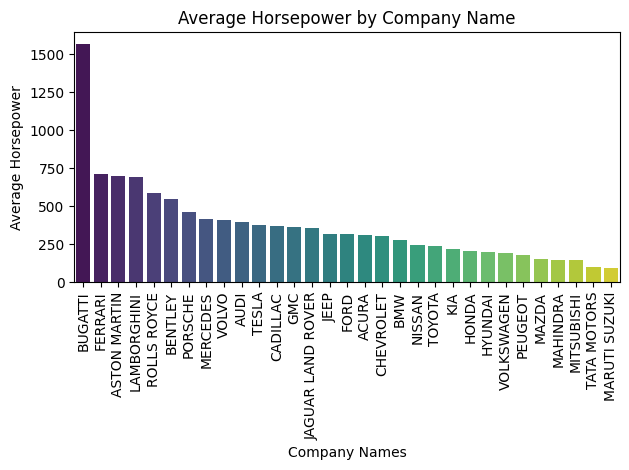

In [48]:
# Average Horsepower by Company Names
avg_company_horsepower = (
    df.groupby('company_names')['horsepower']
    .mean()
    .sort_values(ascending=False) # Puts the largest engines (e.g., Bugatti V8/W16) on the left
    .reset_index()
)

# 2. Plotting using the sorted aggregated data
sns.barplot(
    data=avg_company_horsepower, 
    x='company_names', 
    y='horsepower', 
    hue='company_names',
     palette='viridis' # Uses a nice vibrant color gradient
)


plt.title('Average Horsepower by Company Name')
plt.xlabel('Company Names')
plt.ylabel('Average Horsepower')
plt.xticks(rotation=90)       
plt.tight_layout()            

plt.show()

                         cc_battery_capacity  horsepower  \
cc_battery_capacity                     1.00        0.33   
horsepower                              0.33        1.00   
performance0_-_100_km_h                -0.04       -0.67   
torque                                  0.50        0.77   
total_speed                             0.13        0.74   

                         performance0_-_100_km_h  torque  total_speed  
cc_battery_capacity                        -0.04    0.50         0.13  
horsepower                                 -0.67    0.77         0.74  
performance0_-_100_km_h                     1.00   -0.40        -0.78  
torque                                     -0.40    1.00         0.44  
total_speed                                -0.78    0.44         1.00  


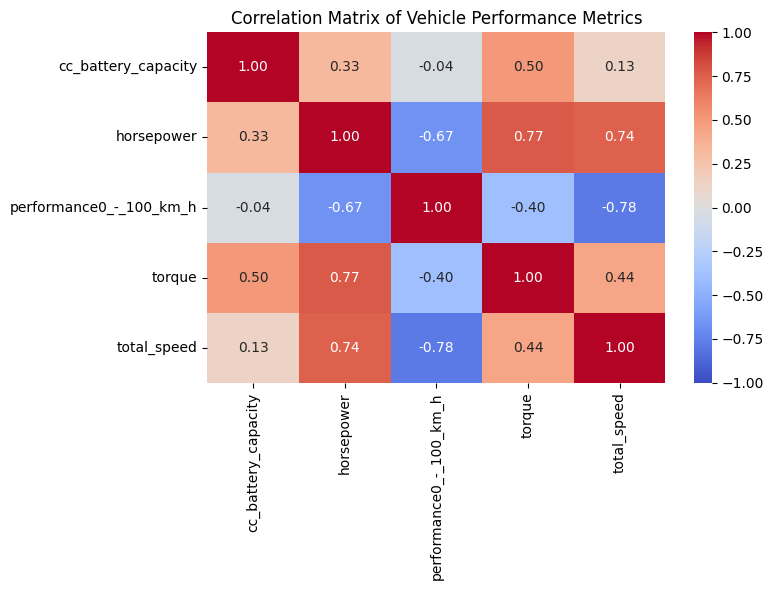

In [49]:
# Correlation Heatmap between Engine Capacity, Performance, Torque and Total Speed
# 1. Selecting engine and performance metrics
corr_columns = ['cc_battery_capacity', 'horsepower', 'performance0_-_100_km_h', 'torque', 'total_speed']
correlation_matrix = df[corr_columns].corr()

# 2. Printing the exact mathematical correlation coefficients (-1 to 1)
print(correlation_matrix)

# 3. Plotting heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Shows the exact correlation number inside each box
    cmap='coolwarm',     # Red = strong positive, Blue = strong negative correlation
    fmt=".2f",           # Rounds the display numbers to 2 decimal places
    vmin=-1, vmax=1      # Standardizes the color bar limits
)

plt.title('Correlation Matrix of Vehicle Performance Metrics')
plt.tight_layout()
plt.show()

In [50]:
# Outlier Analysis for unusually high car prices
'''so to do this it means we need to set a threshold where we think car prices are unusually high, i think finding the standard deviation of car prices and multiplying 
by three(3 * std(cars_prices)) should be reasonable enough to decide whether the price of that car is too high'''

# Calculating the threshold for an "unusually expensive" car
price_mean = df['cars_prices'].mean()
price_std = df['cars_prices'].std()
expensive_threshold = (price_mean + (3 * price_std)).round(2)

print('Higest reasonable Car Price: ',expensive_threshold)
print()

# Filtering for the extreme luxury outliers
outlier_prices = df[df['cars_prices'] > expensive_threshold]

# Displaying them sorted from most to least expensive
expensive_cars = outlier_prices[['company_names', 'cars_prices']].sort_values(by='cars_prices', ascending=False)
print(expensive_cars)


Higest reasonable Car Price:  2278672.6

     company_names  cars_prices
887        BUGATTI  18000000.00
886        BUGATTI   9000000.00
1212         MAZDA   6000000.00
885        BUGATTI   5800000.00
889        BUGATTI   5000000.00
8      LAMBORGHINI   4500000.00
888        BUGATTI   4500000.00
882        BUGATTI   3500000.00
883        BUGATTI   3300000.00
881        BUGATTI   3300000.00
884        BUGATTI   3300000.00
32    ASTON MARTIN   3200000.00
880        BUGATTI   3000000.00
42     LAMBORGHINI   2800000.00


In [51]:
# Outlier Analysis for extremely high horsepower
# Calculating the threshold for extreme horsepower
hp_mean = df['horsepower'].mean()
hp_std = df['horsepower'].std()
hp_threshold = (hp_mean + (3 * hp_std)).round(2)

print('Highest reasonable Horsepower: ', hp_threshold)
print()

# Filtering for horsepower outliers
outlier_hp = df[df['horsepower'] > hp_threshold]

# Displaying them sorted from highest horsepower down
high_hp_cars = outlier_hp[['company_names', 'horsepower', 'cars_prices']].sort_values(by='horsepower', ascending=False)
print(high_hp_cars)

Highest reasonable Horsepower:  928.02

    company_names  horsepower  cars_prices
888       BUGATTI     1850.00   4500000.00
889       BUGATTI     1600.00   5000000.00
886       BUGATTI     1600.00   9000000.00
882       BUGATTI     1600.00   3500000.00
881       BUGATTI     1500.00   3300000.00
885       BUGATTI     1500.00   5800000.00
884       BUGATTI     1500.00   3300000.00
883       BUGATTI     1500.00   3300000.00
880       BUGATTI     1500.00   3000000.00
887       BUGATTI     1500.00  18000000.00
32   ASTON MARTIN     1160.00   3200000.00
33   ASTON MARTIN     1000.00   1100000.00
0         FERRARI      963.00   1100000.00


In [52]:
# 1. Calculate the min and max price for each company
price_spread = df.groupby('company_names')['cars_prices'].agg(['min', 'max']).reset_index()

# 2. Calculate the total range gap
price_spread['price_range_width'] = price_spread['max'] - price_spread['min']

# 3. Sort to find who has the widest variance
widest_ranges = price_spread.sort_values(by='price_range_width', ascending=False)

# Format pandas to display standard decimal numbers clearly
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
print(widest_ranges)


        company_names        min         max  price_range_width
5             BUGATTI 3000000.00 18000000.00        15000000.00
19              MAZDA    9000.00  6000000.00         5991000.00
16        LAMBORGHINI  211000.00  4500000.00         4289000.00
1        ASTON MARTIN  142000.00  3200000.00         3058000.00
8             FERRARI  210000.00  1700000.00         1490000.00
22             NISSAN   10000.00  1100000.00         1090000.00
24            PORSCHE   58000.00   750000.00          692000.00
9                FORD   13500.00   500000.00          486500.00
4                 BMW   26000.00   499000.00          473000.00
2                AUDI   35000.00   253290.00          218290.00
25        ROLLS ROYCE  320000.00   515000.00          195000.00
27              TESLA   40240.00   200000.00          159760.00
20           MERCEDES   46000.00   200000.00          154000.00
28             TOYOTA   18000.00   170000.00          152000.00
29         VOLKSWAGEN   12000.00   15000

# Key Insights

* Vehicle prices vary significantly across manufacturers, with premium and high-performance brands consistently exhibiting higher average prices.

* A positive relationship was observed between horsepower and vehicle price, indicating that more powerful vehicles generally command higher market values.

* Horsepower and top speed demonstrated a strong positive correlation, suggesting that increases in engine power are associated with higher maximum speeds.

* Top speed also showed a positive relationship with vehicle price, although the relationship was less pronounced than that between horsepower and price.

* Manufacturers differed considerably in average acceleration performance, with performance-focused brands achieving lower (0–100 km/h) times.

* Fuel type influenced vehicle performance, with certain categories, such as electric and hybrid vehicles, showing faster average acceleration times than conventional fuel types.

* Significant variation was observed in engine or battery capacities across manufacturers, reflecting differences in market positioning and vehicle design.

* Average vehicle prices differed substantially across manufacturers, highlighting variations in brand positioning and target market segments.

* Outlier analysis identified a small number of vehicles with exceptionally high prices and horsepower values, highlighting the importance of validating extreme observations before drawing conclusions.

* Correlation analysis showed that performance variables such as horsepower, torque, top speed, and acceleration are interconnected and play an important role in determining vehicle pricing.


# Conclusion

This project demonstrated the complete data analysis workflow, from data loading and cleaning to exploratory analysis and insight generation. By transforming raw vehicle data into meaningful information, the analysis uncovered key relationships between pricing, performance, and technical specifications.

The findings indicate that horsepower is a major driver of vehicle price and that manufacturers differ substantially in their performance offerings and pricing strategies. While premium brands generally command higher prices, the analysis showed that higher prices do not necessarily translate to better value for money when performance metrics are considered.

Additionally, the study highlighted the impact of fuel type on vehicle performance and identified significant differences in engine capacity, acceleration, and seating configurations across manufacturers.

Overall, this project demonstrates practical skills in data cleaning, exploratory data analysis, data visualization, feature engineering, and insight generation using Python. The findings provide a clearer understanding of how vehicle performance characteristics influence pricing and how different manufacturers position themselves within the market, basically supporting data-driven decision-making within the automotive industry.
